In [24]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer
import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib import pyplot as plt


In [25]:
# Load the California housing dataset
dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

# Access the target variable (data labels)
target = dataset.target
target_names = dataset.target_names

# Print the name of the target variable
print("target_names")
print(target_names)
# Print the feature names
print("Feature Names:")
print(feature_names)


df = pd.DataFrame(X_full, columns=feature_names)


# Calculate statistics for each feature using the describe() function
statistics = df.describe()

# Display the statistics for each feature
print(statistics)

target_names
['MedHouseVal']
Feature Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count 20640.000 20640.000 20640.000  20640.000   20640.000 20640.000   
mean      3.871    28.639     5.429      1.097    1425.477     3.071   
std       1.900    12.586     2.474      0.474    1132.462    10.386   
min       0.500     1.000     0.846      0.333       3.000     0.692   
25%       2.563    18.000     4.441      1.006     787.000     2.430   
50%       3.535    29.000     5.229      1.049    1166.000     2.818   
75%       4.743    37.000     6.052      1.100    1725.000     3.282   
max      15.000    52.000   141.909     34.067   35682.000  1243.333   

       Latitude  Longitude  
count 20640.000  20640.000  
mean     35.632   -119.570  
std       2.136      2.004  
min      32.540   -124.350  
25%      33.930   -121.800  
50%      34.260   -118.490  
75%  

In [26]:
#Extract specific features from the dataset
features = ["MedInc", "AveOccup"]
features_idx = [list(feature_names).index(feature) for feature in features]
X = X_full[:, features_idx]

# Create a pandas DataFrame with the selected features
df = pd.DataFrame(X, columns=features)


# Calculate statistics for each feature using the describe() function
statistics_ = df.describe()

# Display the statistics for each feature
print(statistics_)

         MedInc  AveOccup
count 20640.000 20640.000
mean      3.871     3.071
std       1.900    10.386
min       0.500     0.692
25%       2.563     2.430
50%       3.535     2.818
75%       4.743     3.282
max      15.000  1243.333


In [27]:
means = np.mean(X, axis=0)
stds = np.std(X, axis=0)
percentiles_25 = np.percentile(X, 25, axis=0)
percentiles_50 = np.percentile(X, 50, axis=0)
percentiles_75 = np.percentile(X, 75, axis=0)

maximums = np.max(X, axis=0)
minimums = np.min(X, axis=0)

# Display the statistics for each feature
for i, feature in enumerate(features):
    print("Feature:", feature)
    print("Mean:", means[i])
    print("Standard Deviation:", stds[i])
    print("25th Percentile:", percentiles_25[i])
    print("50th Percentile (Median):", percentiles_50[i])
    print("75th Percentile:", percentiles_75[i])
    print("Maximum:", maximums[i])
    print("Minimum:", minimums[i])
    print("-" * 40)

Feature: MedInc
Mean: 3.8706710029069766
Standard Deviation: 1.8997756945748738
25th Percentile: 2.5633999999999997
50th Percentile (Median): 3.5347999999999997
75th Percentile: 4.74325
Maximum: 15.0001
Minimum: 0.4999
----------------------------------------
Feature: AveOccup
Mean: 3.0706551594363742
Standard Deviation: 10.385797959128217
25th Percentile: 2.4297411475535755
50th Percentile (Median): 2.818115654360196
75th Percentile: 3.2822609242736216
Maximum: 1243.3333333333333
Minimum: 0.6923076923076923
----------------------------------------


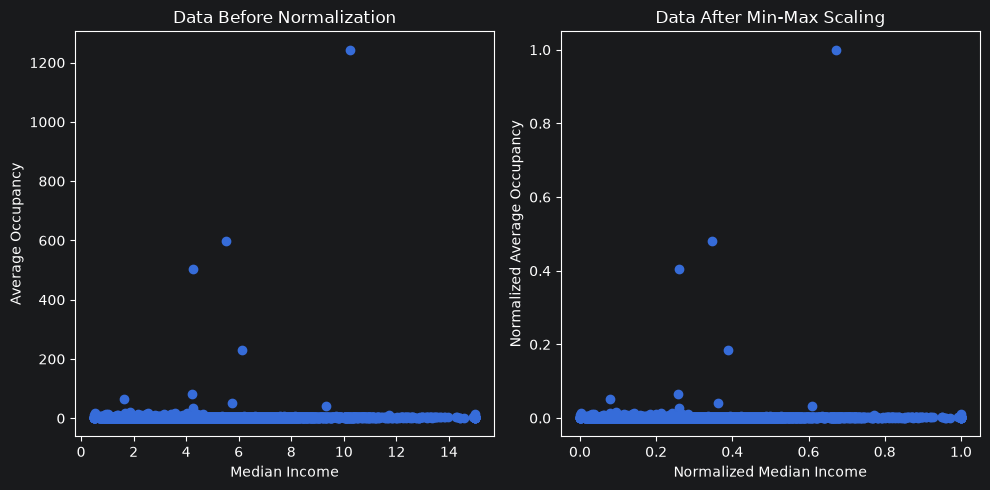

         MedInc  AveOccup
count 20640.000 20640.000
mean      0.232     0.002
std       0.131     0.008
min       0.000     0.000
25%       0.142     0.001
50%       0.209     0.002
75%       0.293     0.002
max       1.000     1.000


In [28]:
scaler=MinMaxScaler()
# Apply Min-Max Scaling to the selected features
X_scaled = scaler.fit_transform(X)

# Plot the data before and after normalization
plt.figure(figsize=(10, 5))

# Plot the data before normalization
plt.subplot(1, 2, 1)
plt.scatter(df["MedInc"], df["AveOccup"])
plt.xlabel("Median Income")
plt.ylabel("Average Occupancy")
plt.title("Data Before Normalization")

# Plot the data after normalization
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel("Normalized Median Income")
plt.ylabel("Normalized Average Occupancy")
plt.title("Data After Min-Max Scaling")

plt.tight_layout()
plt.show()

df_scaled = pd.DataFrame(X_scaled, columns=features)
statistics = df_scaled.describe()
pd.options.display.float_format = '{:.3f}'.format
# Display the statistics for each feature
print(statistics)

X_MinMaxScaler=X_scaled

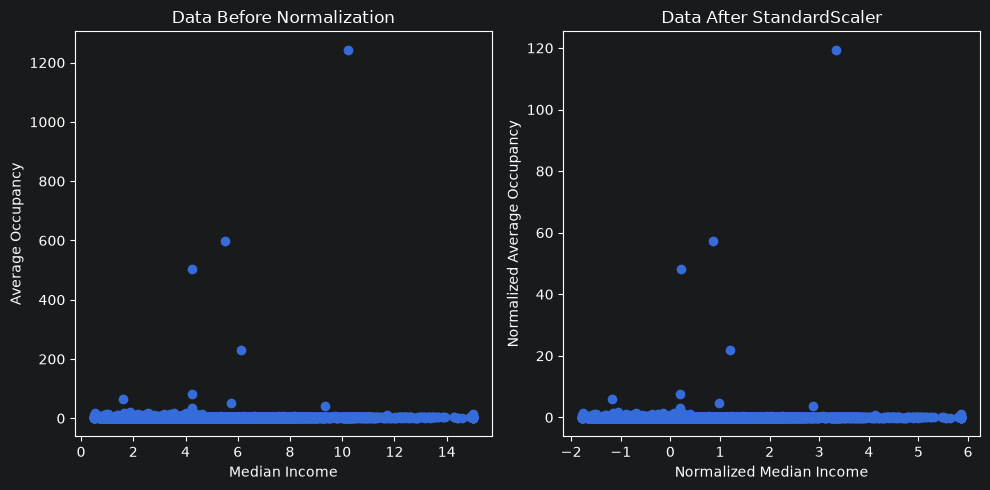

         MedInc  AveOccup
count 20640.000 20640.000
mean      0.000     0.000
std       1.000     1.000
min      -1.774    -0.229
25%      -0.688    -0.062
50%      -0.177    -0.024
75%       0.459     0.020
max       5.858   119.419


In [29]:
# Load the California housing dataset
dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

# Select the desired features
features = ["MedInc", "AveOccup"]
features_idx = [list(feature_names).index(feature) for feature in features]
X = X_full[:, features_idx]
df = pd.DataFrame(X_full, columns=feature_names)

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler Scaling to the selected features
X_scaled = scaler.fit_transform(X)

# Plot the data before and after normalization
plt.figure(figsize=(10, 5))

# Plot the data before normalization
plt.subplot(1, 2, 1)
plt.scatter(df["MedInc"], df["AveOccup"])
plt.xlabel("Median Income")
plt.ylabel("Average Occupancy")
plt.title("Data Before Normalization")

# Plot the data after normalization
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel("Normalized Median Income")
plt.ylabel("Normalized Average Occupancy")
plt.title("Data After StandardScaler")

plt.tight_layout()
plt.show()


df_scaled = pd.DataFrame(X_scaled, columns=features)
statistics = df_scaled.describe()

pd.options.display.float_format = '{:.3f}'.format

# Display the statistics for each feature
print(statistics)

X_StandardScaler=X_scaled

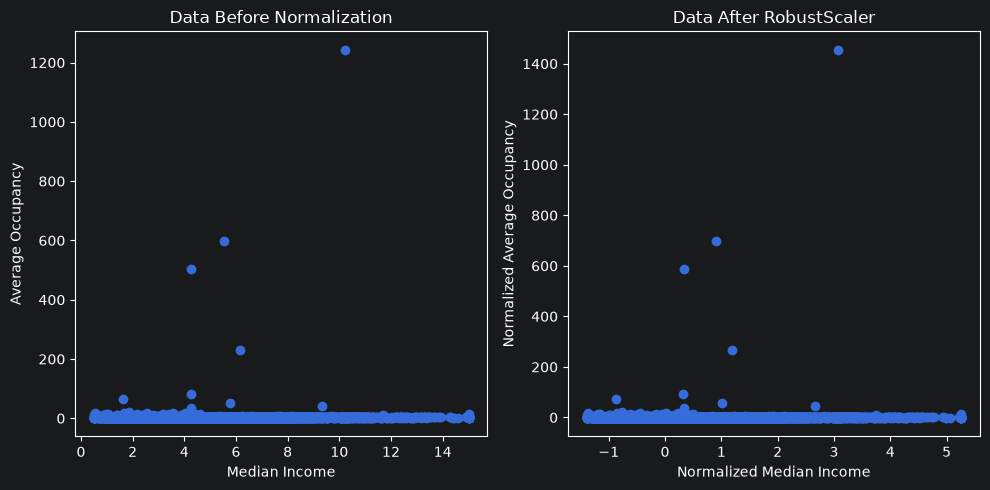

         MedInc  AveOccup
count 20640.000 20640.000
mean      0.154     0.296
std       0.872    12.183
min      -1.392    -2.494
25%      -0.446    -0.456
50%       0.000     0.000
75%       0.554     0.544
max       5.260  1455.116


In [30]:
# Load the California housing dataset
dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

# Select the desired features
features = ["MedInc", "AveOccup"]
features_idx = [list(feature_names).index(feature) for feature in features]
X = X_full[:, features_idx]
df = pd.DataFrame(X_full, columns=feature_names)
# Initialize the RobustScaler
scaler = RobustScaler(quantile_range=(25, 75))


# Apply RobustScaler Scaling to the selected features
X_scaled = scaler.fit_transform(X)

# Plot the data before and after normalization
plt.figure(figsize=(10, 5))

# Plot the data before normalization
plt.subplot(1, 2, 1)
plt.scatter(df["MedInc"], df["AveOccup"])
plt.xlabel("Median Income")
plt.ylabel("Average Occupancy")
plt.title("Data Before Normalization")

# Plot the data after normalization
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel("Normalized Median Income")
plt.ylabel("Normalized Average Occupancy")
plt.title("Data After RobustScaler")

plt.tight_layout()
plt.show()


df_scaled = pd.DataFrame(X_scaled, columns=features)
statistics = df_scaled.describe()

pd.options.display.float_format = '{:.3f}'.format

# Display the statistics for each feature
print(statistics)

X_RobustScaler=X_scaled

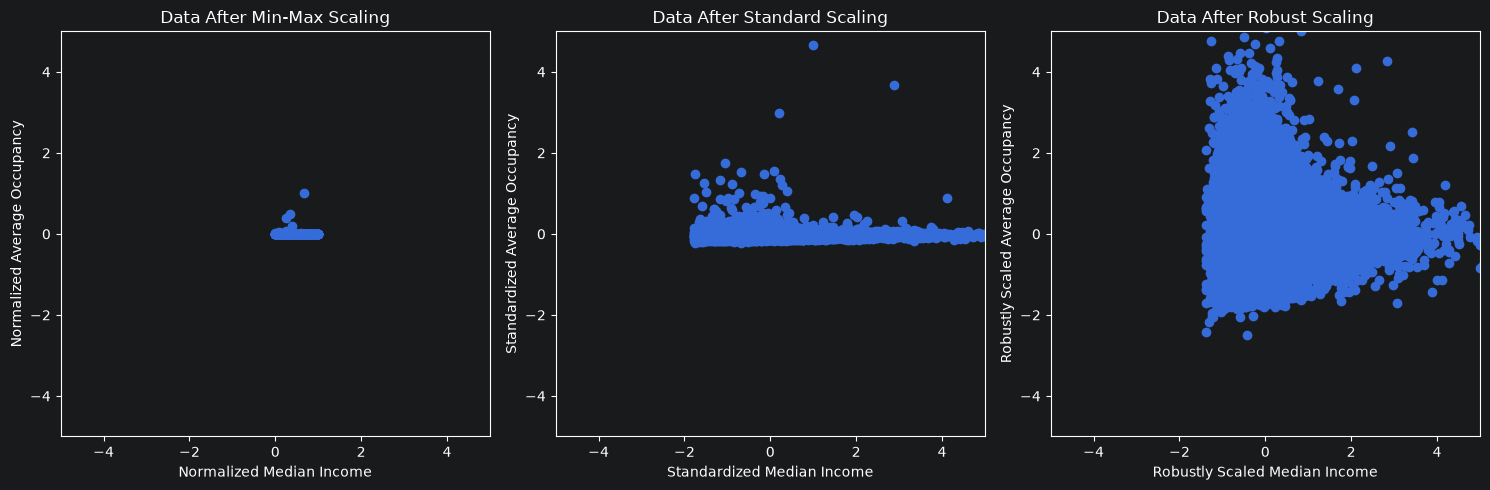

In [31]:
# Plot the data after different scaling methods
plt.figure(figsize=(15, 5))

# Plot the data after Min-Max Scaling
plt.subplot(1, 3, 1)
plt.scatter(X_MinMaxScaler[:, 0], X_MinMaxScaler[:, 1])
plt.xlim(-5, 5)  # Set the x-axis limits for zooming
plt.ylim(-5, 5)  # Set the y-axis limits for zooming
plt.xlabel("Normalized Median Income")
plt.ylabel("Normalized Average Occupancy")
plt.title("Data After Min-Max Scaling")

# Plot the data after Standard Scaling
plt.subplot(1, 3, 2)
plt.scatter(X_StandardScaler[:, 0], X_StandardScaler[:, 1])
plt.xlim(-5, 5)  # Set the x-axis limits for zooming
plt.ylim(-5, 5)  # Set the y-axis limits for zooming
plt.xlabel("Standardized Median Income")
plt.ylabel("Standardized Average Occupancy")
plt.title("Data After Standard Scaling")

# Plot the data after Robust Scaling
plt.subplot(1, 3, 3)
plt.scatter(X_RobustScaler[:, 0], X_RobustScaler[:, 1])
plt.xlim(-5, 5)  # Set the x-axis limits for zooming
plt.ylim(-5, 5)  # Set the y-axis limits for zooming
plt.xlabel("Robustly Scaled Median Income")
plt.ylabel("Robustly Scaled Average Occupancy")
plt.title("Data After Robust Scaling")

plt.tight_layout()
plt.show()

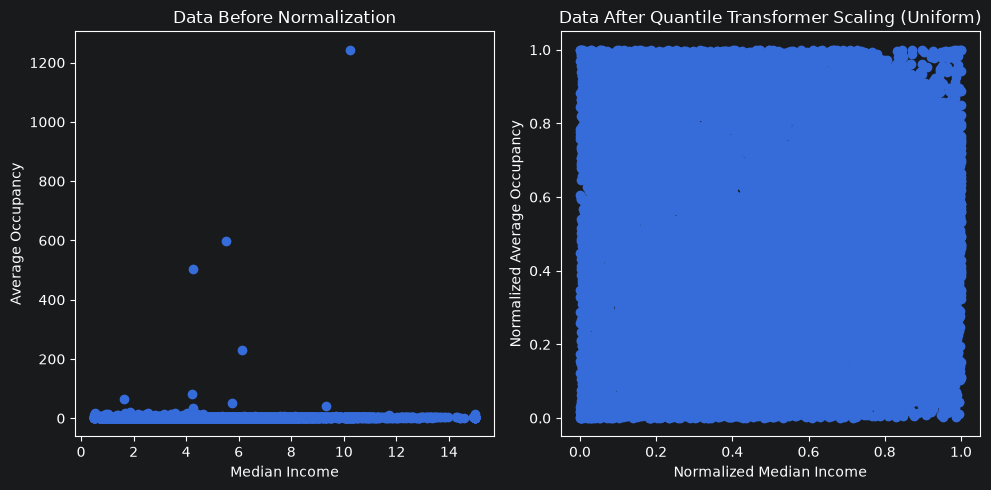

         MedInc  AveOccup
count 20640.000 20640.000
mean      0.500     0.496
std       0.288     0.290
min       0.000     0.000
25%       0.254     0.246
50%       0.497     0.493
75%       0.749     0.746
max       1.000     1.000


In [32]:
# Load the California housing dataset
dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

# Select the desired features
features = ["MedInc", "AveOccup"]
features_idx = [list(feature_names).index(feature) for feature in features]
X = X_full[:, features_idx]
df = pd.DataFrame(X_full, columns=feature_names)
# Initialize the Scaler
scaler =  QuantileTransformer(output_distribution="uniform")

# Apply Scaling to the selected features
X_scaled = scaler.fit_transform(X)

# Plot the data before and after normalization
plt.figure(figsize=(10, 5))

# Plot the data before normalization
plt.subplot(1, 2, 1)
plt.scatter(df["MedInc"], df["AveOccup"])
plt.xlabel("Median Income")
plt.ylabel("Average Occupancy")
plt.title("Data Before Normalization")

# Plot the data after normalization
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel("Normalized Median Income")
plt.ylabel("Normalized Average Occupancy")
plt.title("Data After Quantile Transformer Scaling (Uniform)")

plt.tight_layout()
plt.show()

df_scaled = pd.DataFrame(X_scaled, columns=features)
statistics = df_scaled.describe()
pd.options.display.float_format = '{:.3f}'.format
# Display the statistics for each feature
print(statistics)

X_QuantileTransformer=X_scaled

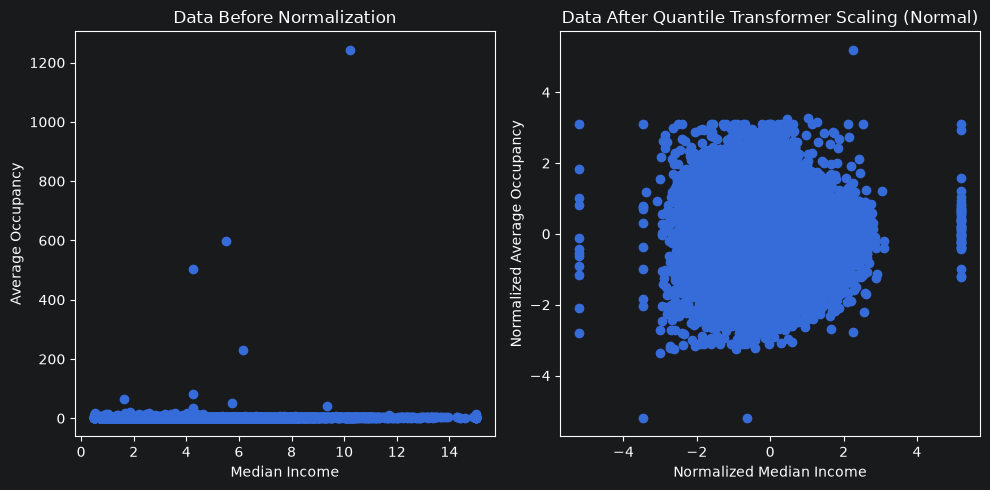

         MedInc  AveOccup
count 20640.000 20640.000
mean      0.009     0.007
std       1.026     1.002
min      -5.199    -5.199
25%      -0.672    -0.679
50%       0.007     0.013
75%       0.677     0.683
max       5.199     5.199


In [33]:
# Load the California housing dataset
dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

# Select the desired features
features = ["MedInc", "AveOccup"]
features_idx = [list(feature_names).index(feature) for feature in features]
X = X_full[:, features_idx]
df = pd.DataFrame(X_full, columns=feature_names)
# Initialize the Scaler
scaler =  QuantileTransformer(output_distribution="normal")

# Apply Scaling to the selected features
X_scaled = scaler.fit_transform(X)

# Plot the data before and after normalization
plt.figure(figsize=(10, 5))

# Plot the data before normalization
plt.subplot(1, 2, 1)
plt.scatter(df["MedInc"], df["AveOccup"])
plt.xlabel("Median Income")
plt.ylabel("Average Occupancy")
plt.title("Data Before Normalization")

# Plot the data after normalization
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel("Normalized Median Income")
plt.ylabel("Normalized Average Occupancy")
plt.title("Data After Quantile Transformer Scaling (Normal)")

plt.tight_layout()
plt.show()

df_scaled = pd.DataFrame(X_scaled, columns=features)
statistics = df_scaled.describe()
pd.options.display.float_format = '{:.3f}'.format
# Display the statistics for each feature
print(statistics)

X_QuantileTransformer=X_scaled
